This notebook implements part 2 of the assessment: **Feedforward Neural Network classifier** for classifying news articles into **Business** or **Sci/Tech**, using **Word2Vec embeddings** trained from scratch on the **AGNews** Dataset

THese are the steps I follow:
1. Data loading and preprocessing
2. Tokenization and padding
3. Train Word2Vec embeddings (gensim)
4. Create embedding matrix for Keras
5. Build and train a Feedforward Neural Network
6. Evaluate with accuracy, precision, recall, F1
7. Prediction function for new text


In [5]:
#Import libraries
import re
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

from gensim.models import Word2Vec
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical

## 1) Load and Inspect Data

In [2]:
df = pd.read_csv("C:/Users/msjka/Downloads/ag_news.csv")
print(df.head())

                                         Description     Label
0  Stocks are posting some early gains this morni...  Business
1  LONDON (Reuters) - Web surfers from Beijing to...  Sci/Tech
2  Microsoft Corp. has put the finishing touches ...  Business
3  Rolls-Royce and Lloyd's of London are among th...  Business
4  Researchers have unveiled genetically engineer...  Sci/Tech


In [6]:
def clean_text(s: str) -> str:
    s = s.lower()
    s = re.sub(r"[^a-z\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

df['clean_tet'] = df[Description].astype(str).apply(clean_text)
df = df[[Description, 'clean_text', label_col]].dropna().reset_index(drop=True)
df.head()


NameError: name 'Description' is not defined

## 3) Encode Labels (Binary)

In [6]:

label_map = {'Business': 0, 'Sci/Tech': 1}
df['label_id'] = df[label_col].map(label_map)
df[['clean_text', label_col, 'label_id']].head()


,clean_text,Label,label_id
0,stocks are posting some early gains this morni...,Business,0
1,london reuters web surfers from beijing to ber...,Sci/Tech,1
2,microsoft corp has put the finishing touches o...,Business,0
3,rolls royce and lloyd s of london are among th...,Business,0
4,researchers have unveiled genetically engineer...,Sci/Tech,1


## 4) Train/Test Split

In [7]:

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'].values, df['label_id'].values,
    test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=df['label_id'].values
)
len(X_train), len(X_test)


(4800, 1200)

## 5) Tokenization & Padding

In [8]:

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

y_train_cat = to_categorical(y_train, num_classes=2)
y_test_cat = to_categorical(y_test, num_classes=2)

X_train_pad.shape, X_test_pad.shape


((4800, 100), (1200, 100))

## 6) Train Word2Vec on Training Data

In [9]:

sentences = [text.split() for text in X_train]
w2v_model = Word2Vec(sentences, vector_size=EMBEDDING_DIM, window=5, min_count=1, workers=4, seed=RANDOM_STATE)

# Build embedding matrix
word_index = tokenizer.word_index
embedding_matrix = np.zeros((min(MAX_VOCAB, len(word_index)+1), EMBEDDING_DIM))

for word, i in word_index.items():
    if i >= MAX_VOCAB:
        continue
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]


## 7) Build Feedforward Neural Network

In [10]:

model = Sequential([
    Embedding(input_dim=embedding_matrix.shape[0],
              output_dim=EMBEDDING_DIM,
              weights=[embedding_matrix],
              input_length=MAX_LEN,
              trainable=False),   # freeze embeddings
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(2, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()


C:\Users\msjka\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     1,264,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,264,700 (4.82 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,264,700 (4.82 MB)

## 8) Train the Model

In [11]:

history = model.fit(
    X_train_pad, y_train_cat,
    epochs=10,
    batch_size=64,
    validation_split=VAL_SPLIT,
    verbose=1
)


Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.5716 - loss: 0.7302 - val_accuracy: 0.6990 - val_loss: 0.5804
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6751 - loss: 0.5885 - val_accuracy: 0.7125 - val_loss: 0.5622
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7010 - loss: 0.5574 - val_accuracy: 0.6958 - val_loss: 0.5970
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6960 - loss: 0.5639 - val_accuracy: 0.7250 - val_loss: 0.5376
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7261 - loss: 0.5215 - val_accuracy: 0.7167 - val_loss: 0.5593
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7240 - loss: 0.5267 - val_accuracy: 0.7229 - val_loss: 0.5608
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7381 - loss: 0.5090 - val_accuracy: 0.7167 - val_loss: 0.5696
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7299 - loss: 0.4994 - val_accuracy: 0.7281 - v

## 9) Evaluation on Test Data

In [12]:

y_pred_prob = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

acc = accuracy_score(y_true, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=['Business', 'Sci/Tech']))


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Accuracy: 0.7242
Precision: 0.6758
Recall:    0.8617
F1-score:  0.7575

Classification Report:

              precision    recall  f1-score   support

    Business       0.81      0.59      0.68       600
    Sci/Tech       0.68      0.86      0.76       600

    accuracy                           0.72      1200
   macro avg       0.74      0.72      0.72      1200
weighted avg       0.74      0.72      0.72      1200



### Confusion Matrix

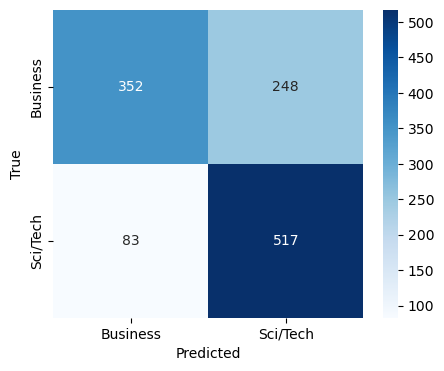

In [13]:

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Business','Sci/Tech'],
            yticklabels=['Business','Sci/Tech'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


## 10) Prediction Function

In [14]:

id_to_label = {0:'Business', 1:'Sci/Tech'}

def predict_article_ffnn(text: str) -> str:
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    pred_id = np.argmax(model.predict(pad), axis=1)[0]
    return id_to_label[pred_id]

# Example usage
print(predict_article_ffnn("Tesla announces new electric car model."))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Sci/Tech
